<a href="https://colab.research.google.com/github/RBOM12/tpValorisationdeladonn-es/blob/main/TP3_BROCHET_Valorisation_de_la_donn%C3%A9es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 3 Valorisation de la données

Apprentissage supervisé (classification) et Intelligence Artificielle eXplicable (LIME & SHAP).

## Apprentissage supervisé : classification

In [1]:
# Imports pour la classification et l'IA explicable
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score

In [2]:
# 1. Chargement du jeu de données Breast Cancer Wisconsin
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Nombre de classes    : {len(np.unique(y))}  ->  {data.target_names}")
print(f"Nombre d'instances   : {X.shape[0]}")
print(f"Nombre de dimensions : {X.shape[1]}")

# Les étiquettes de sklearn sont contre-intuitives : maligne=0, bénigne=1.
# On les inverse pour avoir maligne=1 (présence d'une tumeur) et bénigne=0.
y = 1 - y
print(f"\nAprès inversion  ->  maligne (1) : {(y==1).sum()}  |  bénigne (0) : {(y==0).sum()}")

Nombre de classes    : 2  ->  ['malignant' 'benign']
Nombre d'instances   : 569
Nombre de dimensions : 30

Après inversion  ->  maligne (1) : 212  |  bénigne (0) : 357


Le jeu de données contient **2 classes** (maligne / bénigne), **569 instances** et **30 dimensions** (attributs).

À l'origine l'étiquette `0` correspondait à la tumeur maligne, ce qui est contre-intuitif car 0 = "absence". J'ai donc inversé les étiquettes : maintenant **1 = tumeur maligne** et **0 = tumeur bénigne**.

In [3]:
# 2. Séparation en jeu d'entraînement (70%) et jeu de test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("X_train :", X_train.shape, "|  y_train :", y_train.shape)
print("X_test  :", X_test.shape, "|  y_test  :", y_test.shape)

X_train : (398, 30) |  y_train : (398,)
X_test  : (171, 30) |  y_test  : (171,)


In [4]:
# 3. Normalisation avec le StandardScaler
# On entraîne (fit) le scaler uniquement sur X_train pour ne pas laisser fuiter
# d'information du jeu de test, puis on applique la transformation séparément
# sur X_train et sur X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Moyenne X_train normalisé (3 1ers attributs)    :", np.round(X_train_scaled.mean(axis=0)[:3], 4))
print("Écart-type X_train normalisé (3 1ers attributs) :", np.round(X_train_scaled.std(axis=0)[:3], 4))

Moyenne X_train normalisé (3 1ers attributs)    : [-0. -0. -0.]
Écart-type X_train normalisé (3 1ers attributs) : [1. 1. 1.]


On normalise bien les **attributs** (`X`) et pas les étiquettes (`y`). Le `fit` est fait uniquement sur `X_train` puis appliqué séparément aux deux ensembles : ainsi le jeu de test reste totalement inconnu du modèle au moment de l'entraînement.

In [5]:
# 4. Entraînement d'un classifieur SVM (noyau RBF, probability=True)
# probability=True permet d'obtenir les probabilités d'appartenance aux classes,
# ce qui sera nécessaire pour LIME et SHAP.
clf = SVC(kernel="rbf", probability=True, random_state=42)
clf.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
# 5. Prédictions sur le jeu de test normalisé
y_pred = clf.predict(X_test_scaled)

print("Prédictions (20 premières)  :", y_pred[:20])
print("Vraies étiquettes (20 prem) :", y_test[:20])

Prédictions (20 premières)  : [0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1]
Vraies étiquettes (20 prem) : [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1]


In [7]:
# 6. Évaluation : précision et rappel (classe positive = maligne = 1)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Précision : {precision:.4f}")
print(f"Rappel    : {recall:.4f}")

Précision : 0.9683
Rappel    : 0.9683


La précision et le rappel valent tous les deux **0.97** environ.

- La **précision** (0.97) signifie que parmi les patients que le modèle prédit comme "maligne", 97 % avaient réellement une tumeur maligne (peu de fausses alertes).
- Le **rappel** (0.97) signifie que le modèle identifie 97 % des patients qui ont réellement une tumeur maligne (peu de cas manqués, ce qui est primordial dans un contexte médical).

Le classifieur SVM est donc très performant sur ce jeu de données.

## LIME

In [8]:
# 1. Installation de LIME dans l'environnement TP_VD
!pip install lime


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# 2. Instanciation de l'explainer LIME
from lime.lime_tabular import LimeTabularExplainer

# On fournit les données d'entraînement normalisées, les noms des attributs,
# les noms des classes, le mode (classification) et un random_state pour la reproductibilité.
explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=data.feature_names,
    class_names=["bénigne (0)", "maligne (1)"],
    mode="classification",
    random_state=42,
)

In [10]:
# 3. Classe prédite et explication de l'instance d'indice 10 du jeu de test
idx = 10
classe_predite = clf.predict(X_test_scaled[idx].reshape(1, -1))[0]
proba = clf.predict_proba(X_test_scaled[idx].reshape(1, -1))[0]

print(f"Instance n°{idx}")
print(f"Classe prédite : {classe_predite} ({explainer.class_names[classe_predite]})")
print(f"Probabilités   : bénigne = {proba[0]:.3f}  |  maligne = {proba[1]:.3f}")
print(f"Vraie classe   : {y_test[idx]}")

# On explique bien la classe prédite (paramètre labels)
explication = explainer.explain_instance(
    X_test_scaled[idx],
    clf.predict_proba,
    num_features=10,
    labels=(classe_predite,),
)

Instance n°10
Classe prédite : 0 (bénigne (0))
Probabilités   : bénigne = 0.955  |  maligne = 0.045
Vraie classe   : 0


Le modèle prédit la classe **0 (bénigne)** pour l'instance n°10, avec une probabilité d'environ **95 %**. C'est cohérent avec la vraie étiquette (`y_test[10] = 0`), la prédiction est donc correcte.

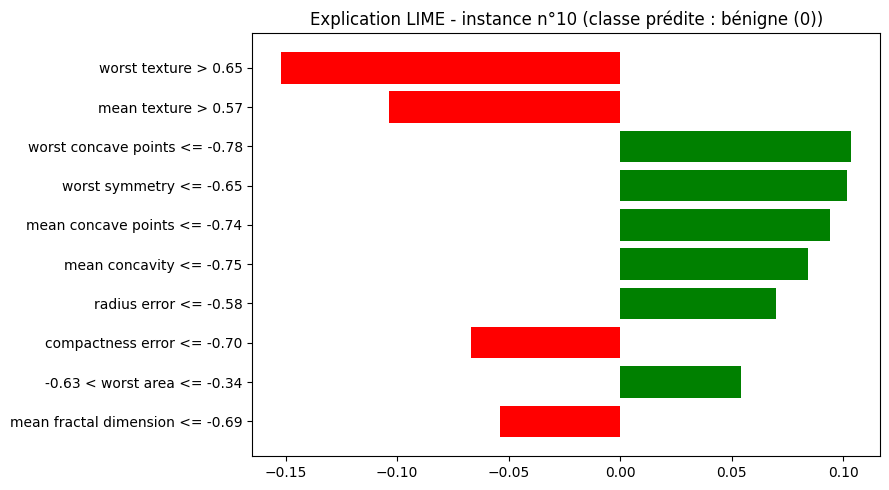

In [11]:
# 4. Visualisation de l'explication (as_pyplot_figure)
fig = explication.as_pyplot_figure(label=classe_predite)
fig.set_size_inches(9, 5)
plt.title(f"Explication LIME - instance n°{idx} (classe prédite : {explainer.class_names[classe_predite]})")
plt.tight_layout()
plt.show()

L'explication montre, pour chaque attribut, dans quelle mesure il pousse la prédiction **vers** la classe bénigne (barres positives, en vert) ou **contre** elle (barres négatives, en rouge).

Les attributs les plus importants sont liés à la **texture** (`worst texture`, `mean texture`) et aux **points concaves** (`worst concave points`, `mean concave points`), ainsi qu'à la **symétrie** (`worst symmetry`). Une texture élevée tire vers la classe maligne, tandis que des valeurs faibles de points concaves / concavité soutiennent la classe bénigne, ce qui explique la prédiction "bénigne".

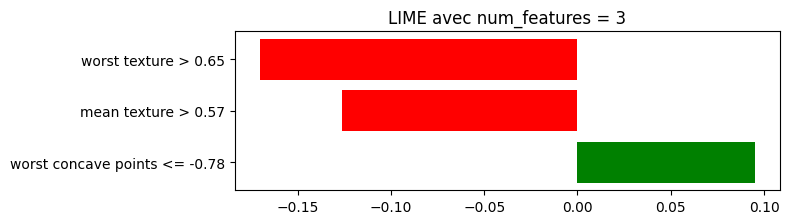

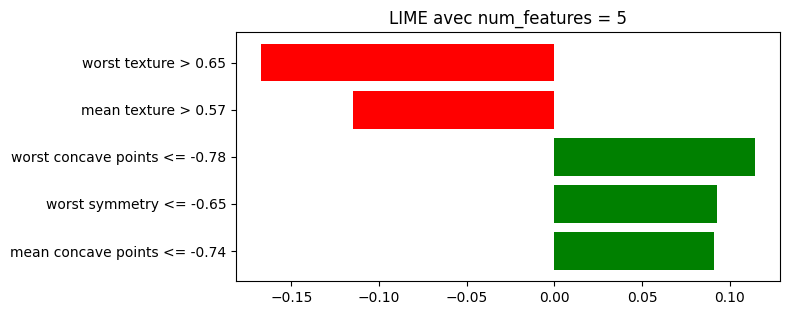

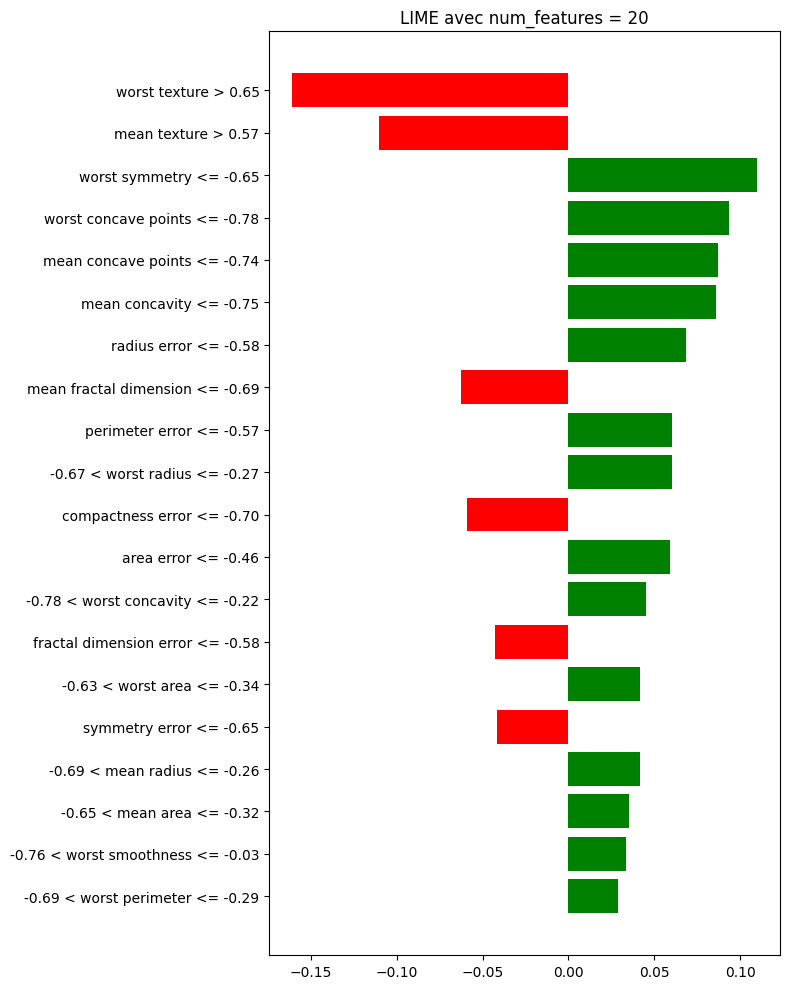

In [12]:
# 6. On fait varier le nombre d'attributs de l'explication (num_features)
for nb in [3, 5, 20]:
    exp_nb = explainer.explain_instance(
        X_test_scaled[idx], clf.predict_proba,
        num_features=nb, labels=(classe_predite,),
    )
    fig = exp_nb.as_pyplot_figure(label=classe_predite)
    fig.set_size_inches(8, 0.45 * nb + 1)
    plt.title(f"LIME avec num_features = {nb}")
    plt.tight_layout()
    plt.show()

Plus on augmente `num_features`, plus l'explication détaille d'attributs. Avec peu d'attributs (3) on ne garde que les plus déterminants ; avec beaucoup (20) on voit apparaître des attributs au poids très faible qui n'apportent presque rien. Les attributs principaux (texture, points concaves) restent les mêmes quel que soit le nombre choisi : l'explication est stable.

Instance n°1  ->  classe prédite : 1 (maligne (1))  |  vraie classe : 1


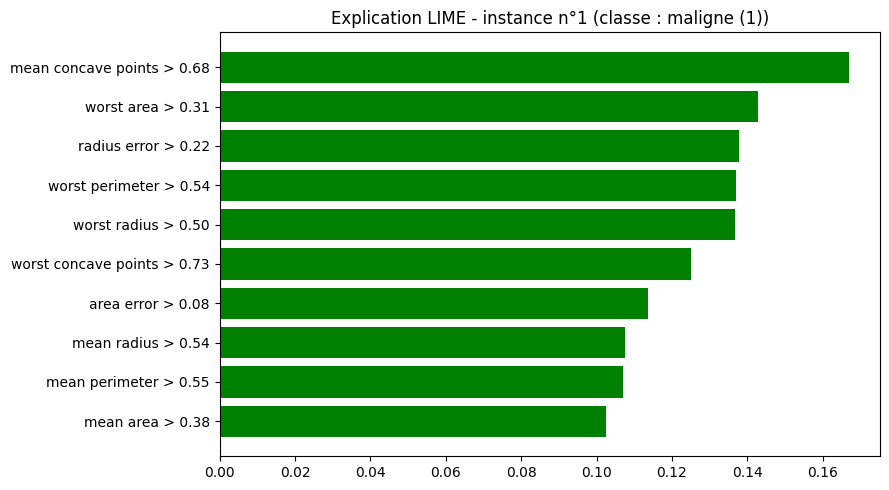

In [13]:
# 7. Explication d'une autre instance : on choisit une tumeur prédite maligne
idx2 = int(np.where(y_pred == 1)[0][0])   # première instance prédite maligne
cp2 = clf.predict(X_test_scaled[idx2].reshape(1, -1))[0]
print(f"Instance n°{idx2}  ->  classe prédite : {cp2} ({explainer.class_names[cp2]})  |  vraie classe : {y_test[idx2]}")

exp2 = explainer.explain_instance(
    X_test_scaled[idx2], clf.predict_proba,
    num_features=10, labels=(cp2,),
)
fig = exp2.as_pyplot_figure(label=cp2)
fig.set_size_inches(9, 5)
plt.title(f"Explication LIME - instance n°{idx2} (classe : {explainer.class_names[cp2]})")
plt.tight_layout()
plt.show()

Pour une instance prédite **maligne**, les contributions s'inversent : ce sont maintenant les valeurs **élevées** de texture, de points concaves et de concavité qui poussent fortement vers la classe maligne. L'explication est cohérente avec ce que l'on attend médicalement, et on a pu réutiliser le même objet `explainer`.

## SHAP

In [14]:
# 1. Installation de SHAP dans l'environnement TP_VD
!pip install shap


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# 2. Instanciation de l'explainer SHAP
# La classe Sampling calcule des approximations des valeurs de Shapley.
import shap

shap_explainer = shap.explainers.Sampling(clf.predict_proba, X_train_scaled)

C:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# 3. Calcul des valeurs SHAP de l'instance d'indice 10 du jeu de test normalisé
shap_values = shap_explainer.shap_values(X_test_scaled[idx])

print("Forme des valeurs SHAP :", np.asarray(shap_values).shape, " (attributs x classes)")
print("Valeur attendue (expected_value) :", np.round(shap_explainer.expected_value, 4))

Forme des valeurs SHAP : (30, 2)  (attributs x classes)
Valeur attendue (expected_value) : [0.626 0.374]


In [17]:
# 4. Affichage des valeurs SHAP pour la classe prédite, triées par importance
shap_classe = shap_values[:, classe_predite]
ordre = np.argsort(np.abs(shap_classe))[::-1]

print(f"Valeurs SHAP pour la classe '{explainer.class_names[classe_predite]}' (instance n°{idx}) :\n")
for i in ordre[:10]:
    print(f"   {shap_classe[i]:+.4f}   {data.feature_names[i]}")

Valeurs SHAP pour la classe 'bénigne (0)' (instance n°10) :

   +0.0524   worst concave points
   -0.0521   worst texture
   +0.0474   worst concavity
   +0.0442   mean concave points
   +0.0426   worst symmetry
   -0.0411   mean texture
   +0.0380   mean concavity
   +0.0333   worst radius
   +0.0316   worst perimeter
   +0.0308   radius error


Chaque valeur SHAP indique la contribution d'un attribut à l'écart entre la prédiction de l'instance et la prédiction moyenne (`expected_value`). Une valeur **positive** augmente la probabilité de la classe bénigne, une valeur **négative** la diminue.

Ici les attributs qui ressortent sont `worst concave points`, `worst texture`, `mean concave points`, `worst concavity` et `worst symmetry` : ce sont essentiellement les mêmes attributs que ceux mis en avant par LIME.

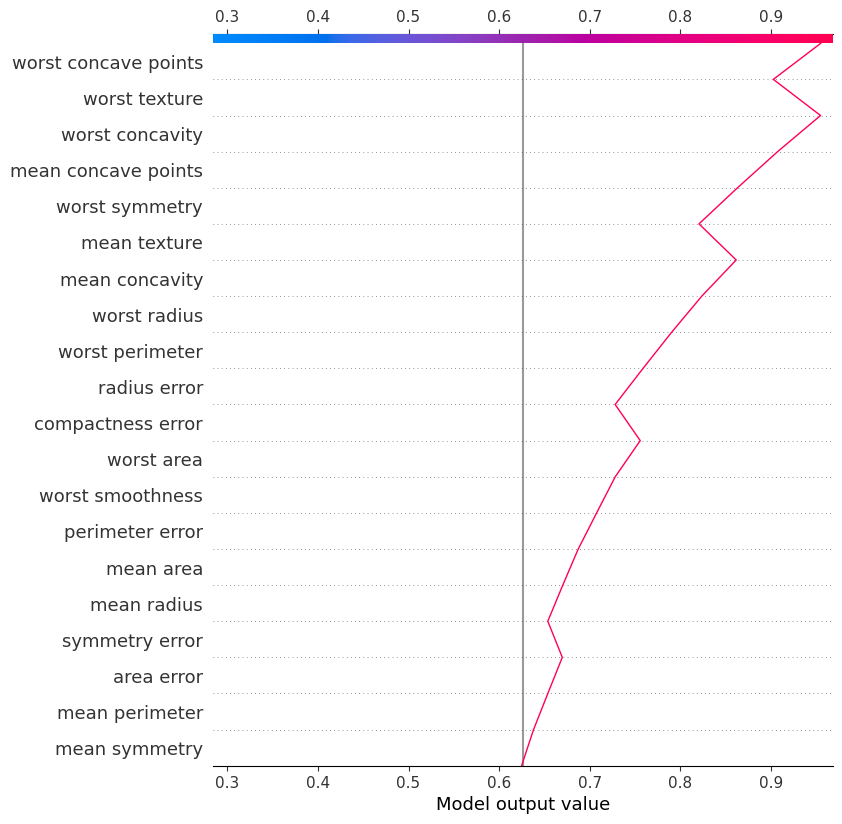

In [18]:
# 5. Visualisation avec le decision plot (classe prédite uniquement)
# Premier argument = prédiction moyenne (expected_value) de la classe considérée.
shap.plots.decision(
    shap_explainer.expected_value[classe_predite],
    shap_values[:, classe_predite],
    feature_names=list(data.feature_names),
)

Le *decision plot* part de la prédiction moyenne (en bas) et empile, attribut par attribut, leur contribution jusqu'à la prédiction finale (en haut). On lit ainsi comment chaque attribut déplace la décision. Les attributs les plus importants sont, là encore, ceux liés à la **texture** et aux **points concaves / concavité**, qui font basculer la décision vers la classe bénigne.

**Comparaison LIME / SHAP.** Les deux méthodes désignent les **mêmes attributs déterminants** (texture, points concaves, symétrie) avec des signes cohérents, ce qui renforce la confiance dans l'explication.

- **LIME** ajuste un modèle linéaire local autour de l'instance : les poids sont relatifs et l'explication peut légèrement varier selon l'échantillonnage.
- **SHAP** repose sur les valeurs de Shapley : les contributions sont **additives** (elles s'ajoutent à `expected_value` pour reconstituer exactement la prédiction), ce qui donne une explication théoriquement plus fondée et plus stable, au prix d'un temps de calcul plus élevé.

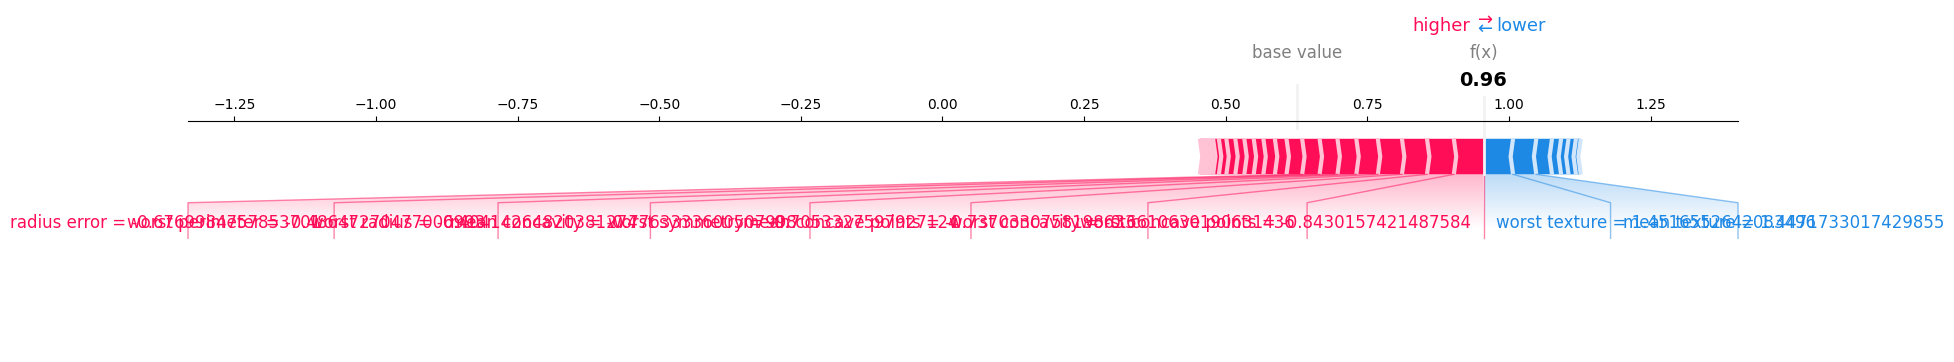

In [19]:
# 8. Visualisation avec le force plot (classe prédite, version matplotlib)
shap.plots.force(
    shap_explainer.expected_value[classe_predite],
    shap_values[:, classe_predite],
    features=X_test_scaled[idx],
    feature_names=list(data.feature_names),
    matplotlib=True,
)

Par rapport au *decision plot*, le *force plot* montre sur un **axe horizontal** la "poussée" de chaque attribut : les forces en rouge poussent la prédiction vers le haut et celles en bleu vers le bas, autour de la valeur de base. Information supplémentaire : il affiche **la valeur réelle de chaque attribut** à côté de sa contribution, et la position finale `f(x)` par rapport à la moyenne, ce qui rend la lecture de l'amplitude des forces plus directe.

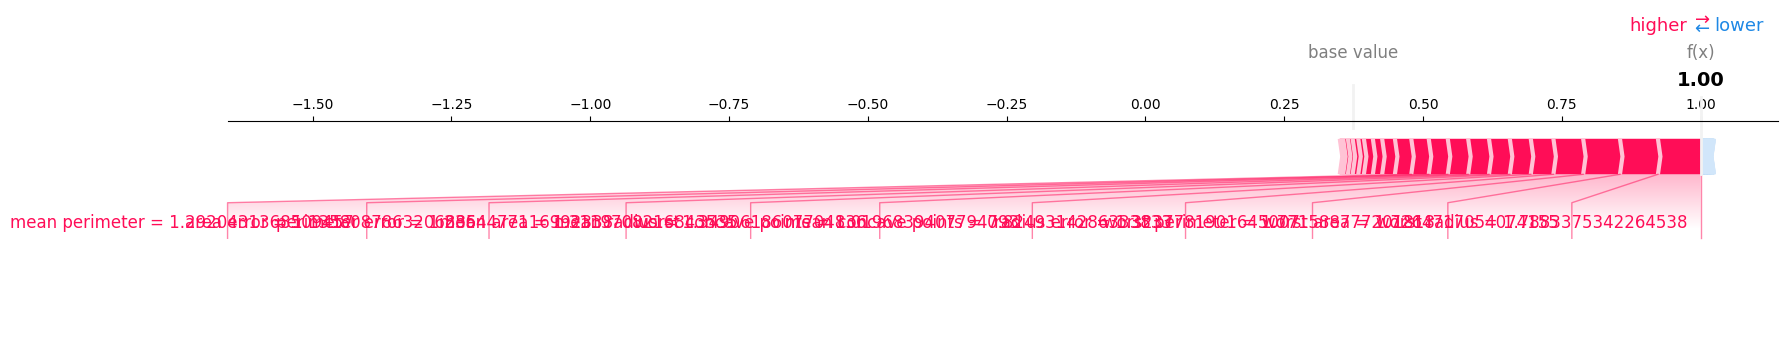

In [20]:
# 9. Explication SHAP d'une autre instance (la même tumeur maligne que pour LIME)
shap_values2 = shap_explainer.shap_values(X_test_scaled[idx2])
shap.plots.force(
    shap_explainer.expected_value[cp2],
    shap_values2[:, cp2],
    features=X_test_scaled[idx2],
    feature_names=list(data.feature_names),
    matplotlib=True,
)

Pour cette instance prédite **maligne**, le force plot montre que les attributs de texture, de points concaves et de concavité poussent cette fois la prédiction dans l'autre sens. LIME et SHAP fournissent des explications convergentes : le modèle s'appuie de façon cohérente sur un petit groupe d'attributs (texture, points concaves, concavité, symétrie) pour distinguer les tumeurs malignes des bénignes.